In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from umap import UMAP

hidden_states = torch.load('../figures/llama/llama_sequence_embeddings.tensors', weights_only=True)
hidden_states = [torch.concat(hs, dim=0).cpu().float().numpy() for hs in hidden_states]

/home/fdong/miniconda3/envs/moe/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


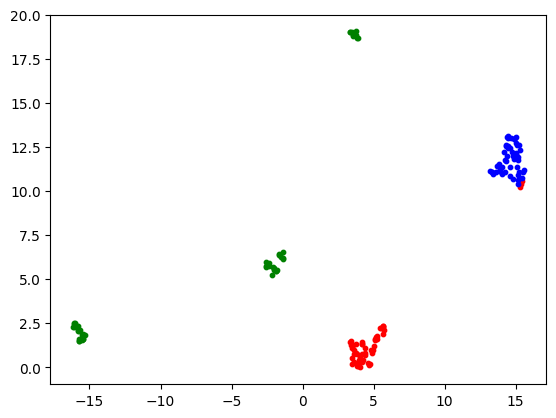

In [ ]:
colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'black', 'pink', 'brown', 'gray']

layer = 6
for layer in range(len(hidden_states)):
    hss = hidden_states[layer]
    hss_2d = UMAP(n_components=2).fit_transform(hss)
    plt.close()
    for i in range(0, len(hss), 50):
        plt.scatter(hss_2d[i : i + 50, 0], hss_2d[i : i + 50, 1], color=colors[i//50], s=10)
    # plt.scatter(hss_2d[:, 0], hss_2d[:, 1], s=10)/
    plt.savefig(f'../figures/llama/llama_layer_{layer}.png')

In [3]:
sg_embeddings = torch.load('../figures/llama/llama_token_embeddings.tensors', weights_only=True)
# sg_embeddings = [sg.numpy() for sg in sg_embeddings]

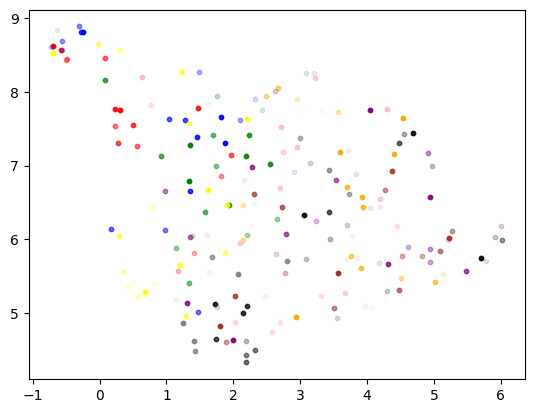

In [5]:
colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'black', 'pink', 'brown', 'gray']

for layer in range(25):
    sgs = []
    sentence_tokens = sg_embeddings[layer]
    plt.close()
    for i, tokens in enumerate(sentence_tokens):
        if i >= len(colors):
            break
        tokens = tokens[0] #[1, len, 2048]
        for j in range(10, 200 + 1, 10):
            sgs.append(tokens[:j].mean(0).float().cpu().numpy())
            # sgs.append(tokens[j].float().cpu().numpy())

    sgs = UMAP(n_components=2).fit_transform(sgs)
    for i in range(0, len(sgs), 20):
        for j in range(0, 20):
            plt.scatter(sgs[i + j, 0], sgs[i + j, 1], color=colors[i // 20], s=10, alpha= (j + 1) / 20)

    plt.savefig(f'../figures/llama/llama_token_layer_{layer}.png')